# Model Evaluation and Robustness Analysis

This notebook evaluates the classification performance and adversarial robustness of a trained ResNet-18 model on the CIFAR-10 test set. Both quantitative metrics and qualitative visualizations are included in order to assess how the model behaves on clean and adversarially perturbed inputs.

## Setup

This section imports the required libraries, defines the computational device, and applies a consistent plotting style for all visualizations presented in the notebook.

In [1]:
import torchvision
from torchvision.transforms import v2
import torch
import torch.nn.functional as F

from torchmetrics.classification import MulticlassConfusionMatrix

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

from thesis_adversarial import resnet18, PGDAttack, FGSMAttack

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu') 

In [2]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams["font.family"] = "serif"

## Dataset Preparation

The CIFAR-10 test set is used for evaluation. No data augmentation is applied, as the purpose of this notebook is to assess model performance on the original test distribution and under adversarial perturbations.

In [ ]:
transform_test = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])

testset = torchvision.datasets.CIFAR10(root='../data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=100, shuffle=False, num_workers=2)

In [4]:
dataiter = iter(testloader)
images, labels = next(dataiter)

classes = ('Airplane', 'Car', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck')

## Evaluation Utilities

The helper functions defined below are used to compute performance metrics and generate visualizations.

In [5]:
def evaluate_clean_performance(model, testloader):
    correct, total = 0, 0
    running_loss = 0
    
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        
        with torch.no_grad():
            outputs = model(images)
            
            loss = F.cross_entropy(outputs, labels)
        
        running_loss += loss.item() * images.size(0)
            
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    acc = correct / total
    avg_loss = running_loss / total
    
    return acc, avg_loss

In [6]:
def evaluate_adversarial_performace(model, testloader, attack):
    correct, total = 0, 0
    running_loss = 0
    
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        adv_images = attack.perturb(images, labels)        
        
        with torch.no_grad():  
            outputs = model(adv_images)  
            
            loss = F.cross_entropy(outputs, labels)
        
        running_loss += loss.item() * images.size(0)
            
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
            
    acc = correct / total
    avg_loss = running_loss / total
    
    return acc, avg_loss 

In [7]:
def evaluate_model_robustness(model, testloader, epsilons):
    clean_acc, clean_avg_loss = evaluate_clean_performance(model, testloader)
    
    print(f'Clean accuracy: {clean_acc*100:.2f}% | Clean avg loss: {clean_avg_loss:.4f}')
    
    for e in epsilons: 
        fgsm = FGSMAttack(model, e)
        adv_acc_fgsm, adv_avg_loss_fgsm = evaluate_adversarial_performace(model, testloader, fgsm)
        print(f'FGSM epsilon = {e}')
        print(f'Adversarial accuracy: {adv_acc_fgsm*100:.2f}% | Adversarial avg loss: {adv_avg_loss_fgsm:.4f}')
        
        pgd = PGDAttack(model, e, steps=10, alpha=0.006)
        adv_acc_pgd, adv_avg_loss_pgd = evaluate_adversarial_performace(model, testloader, pgd)
        print(f'PGD epsilon = {e}')
        print(f'Adversarial accuracy: {adv_acc_pgd*100:.2f}% | Adversarial avg loss: {adv_avg_loss_pgd:.4f}\n')

In [8]:
def generate_adversarial_example(image, label, attack):
    image = image.to(device)
    label = label.to(device)
    
    image_adv = attack.perturb(image.unsqueeze(0), label.unsqueeze(0))
    
    return image_adv[0]

In [9]:
def plot_adversarial_example_comparison(model, image, label, attack):
    fig, ax = plt.subplots(1,3, figsize=(8, 8))
    image = image.to(device)
    label = label.to(device)
    image_adv = attack.perturb(image.unsqueeze(0), label.unsqueeze(0))
    
    with torch.no_grad():
        logits = model(image.unsqueeze(0))
        logits_adv = model(image_adv)
    
    predicted = logits.argmax(dim=1).item()
    predicted_adv = logits_adv.argmax(dim=1).item()
    
    confidence = F.softmax(logits, dim=1).max().item()
    adv_confidence = F.softmax(logits_adv, dim=1).max().item()
        
    ax[0].imshow(np.transpose(image.detach().cpu().numpy(), (1, 2, 0)))
    ax[0].set_title(f'Clean Image, {classes[predicted]}, {confidence*100:.2f}%', fontsize=10)
    ax[0].set_axis_off()

    diff = (image_adv[0] - image).mean(dim=0).detach().cpu().numpy()
    ax[1].imshow(diff, cmap='seismic', vmin=-0.03, vmax=0.03)
    ax[1].set_title('Differences', fontsize=10)
    ax[1].set_axis_off()
 
    ax[2].imshow(np.transpose(image_adv[0].detach().cpu().numpy(), (1, 2, 0)))
    ax[2].set_title(f'Adversarial Image, {classes[predicted_adv]}, {adv_confidence*100:.2f}%', fontsize=10)
    ax[2].set_axis_off()

    plt.subplots_adjust(wspace=0.1, hspace=0.3)
    plt.show()

In [10]:
def plot_grad_cam(model, image, path=None):
    fig, ax = plt.subplots(1, 2, figsize=(8, 3.5), constrained_layout=True)
    
    target_layers = [model.layer4[-1]]

    input_tensor = image.unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits = model(input_tensor)
        
    pred_class = logits.argmax(dim=1).item()    
    targets = [ClassifierOutputTarget(pred_class)]
    
    condidence = F.softmax(logits, dim=1).max().item()
    
    with GradCAM(model=model, target_layers=target_layers) as cam:
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
    
    rgb_img = image.detach().cpu().numpy()
    rgb_img = np.transpose(rgb_img, (1, 2, 0))
    
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    ax[0].set_title(f'Prediction: {classes[pred_class]}', fontsize=20)
    ax[0].imshow(visualization)
    ax[0].set_axis_off()
    
    ax[1].set_title(f'Confidence {condidence*100:.2f}%', fontsize=20)
    ax[1].imshow(rgb_img)
    ax[1].set_axis_off()
    
    if path is not None:
        plt.savefig(path, dpi=300, bbox_inches='tight', format='pdf')

    plt.show()

In [11]:
def plot_confusion_matrix(model, testloader, normalize='none', attack=None, path=None):
    metric = MulticlassConfusionMatrix(num_classes=10, normalize=normalize).to(device)
    model.eval()
    metric.reset()
    
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        if attack is not None:
            inputs = attack.perturb(inputs, labels)

        with torch.no_grad():
            outputs = model(inputs)
            
        metric.update(outputs, labels)

    fig, ax = plt.subplots(figsize=(7.5, 7.5))
    ax.grid(False)
    
    metric.plot(ax=ax, labels=[c for c in classes])
    
    if path is not None:
        fig.savefig(path, dpi=300, bbox_inches='tight', format='pdf')
    
    plt.show()
    

In [12]:
def get_confidences(model, dataloader, device, attack=None):
    model.eval()

    correct_confidences = []
    incorrect_confidences = []

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        if attack is not None:
            inputs = attack.perturb(inputs, labels)

        with torch.no_grad():
            logits = model(inputs)
            probabilities = F.softmax(logits, dim=1)
            max_confidence, predicted = torch.max(probabilities, dim=1)

        correct_mask = predicted == labels
        incorrect_mask = predicted != labels

        correct_confidences.extend(max_confidence[correct_mask].cpu().tolist())
        incorrect_confidences.extend(max_confidence[incorrect_mask].cpu().tolist())

    return correct_confidences, incorrect_confidences

In [13]:
def plot_confidence_histograms(confidences, titles, save_path=None):
    colors = ["lightskyblue", "orange", "lightgreen", "orchid"]

    fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, confidence_values, title, color in zip(axes, confidences, titles, colors):
        confidence_values = np.array(confidence_values)

        if len(confidence_values) > 0:
            weights = np.full(len(confidence_values), 100 / len(confidence_values))

            ax.hist(
                confidence_values,
                bins=20,
                range=(0, 1),
                weights=weights,
                color=color,
                edgecolor='whitesmoke'
            )

        ax.set_title(title)
        ax.set_xlim(0, 1)
        ax.yaxis.set_major_formatter(PercentFormatter())

    fig.supxlabel("Confidence")
    fig.supylabel("Percent of Correctly Classified Samples")

    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight", format="pdf")
    plt.show()

## Evaluation Configuration

The following parameters define the path to the trained model weights and the attack settings used during evaluation.

In [14]:
path_to_model = '../models/model_adversarial_training_best.pt' # Change this to try another model.

pgd_epsilon = 0.03
steps = 10
alpha = 0.006

fgsm_epsilon = 0.03

## Model Loading

In this section, the selected trained model is loaded from disk and set to evaluation mode. The corresponding attack objects are then initialized using the chosen evaluation parameters.

In [15]:
model = resnet18().to(device)
model.load_state_dict(torch.load(path_to_model, weights_only=True, map_location=device))
model.eval()

ResNet(
  (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias

In [16]:
pgd_attack = PGDAttack(model, pgd_epsilon, steps, alpha)
fgsm_attack = FGSMAttack(model, fgsm_epsilon)

### Adversarial Example

This visualization compares the original image, the perturbation pattern, and the adversarial image. This illustrates how small input changes can affect the model's predicted class and confidence.

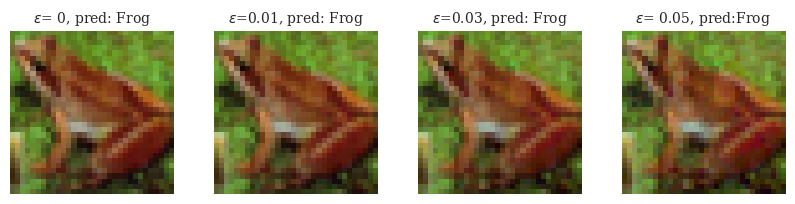

In [17]:
idx = 29

attack_1 = PGDAttack(model, 0.01, 10, 0.006)
attack_2 = PGDAttack(model, 0.03, 10, 0.006)
attack_3 = PGDAttack(model, 0.05, 10, 0.006)

image = images[idx].to(device)
label = labels[idx].to(device)

image_1 = generate_adversarial_example(image, label, attack_1)
image_2 = generate_adversarial_example(image, label, attack_2)
image_3 = generate_adversarial_example(image, label, attack_3)

with torch.no_grad():
    logits_clean = model(image.unsqueeze(0))
    logits_1 = model(image_1.unsqueeze(0))
    logits_2 = model(image_2.unsqueeze(0))
    logits_3 = model(image_3.unsqueeze(0))

prediction_clean = logits_clean.argmax(dim=1).item()
prediction_1 = logits_1.argmax(dim=1).item()
prediction_2 = logits_2.argmax(dim=1).item()
prediction_3 = logits_3.argmax(dim=1).item()
 


fig, ax = plt.subplots(1,4, figsize=(10, 10))

ax[0].imshow(np.transpose(image.detach().cpu().numpy(), (1, 2, 0)))
ax[0].set_title(f'$\\epsilon$= 0, pred: {classes[prediction_clean]}', fontsize=10)
ax[0].set_axis_off()

ax[1].imshow(np.transpose(image_1.detach().cpu().numpy(), (1, 2, 0)))
ax[1].set_title(f'$\\epsilon$=0.01, pred: {classes[prediction_1]}', fontsize=10)
ax[1].set_axis_off()

ax[2].imshow(np.transpose(image_2.detach().cpu().numpy(), (1, 2, 0)))
ax[2].set_title(f'$\\epsilon$=0.03, pred: {classes[prediction_2]}', fontsize=10)
ax[2].set_axis_off()

ax[3].imshow(np.transpose(image_3.detach().cpu().numpy(), (1, 2, 0)))
ax[3].set_title(f'$\\epsilon$= 0.05, pred:{classes[prediction_3]} ', fontsize=10)
ax[3].set_axis_off()

plt.subplots_adjust(wspace=0.25, hspace=1)
plt.show()

### Clean and Adversarial Performance

The model is first evaluated on clean test images and then under FGSM and PGD attacks with perturbation strengths ranging from $\epsilon = 0.01$ to $\epsilon = 0.06$, using a step size of $0.006$. This makes it possible to assess how model performance deteriorates as the magnitude of the adversarial perturbation increases.

In [18]:
evaluate_model_robustness(model, testloader, epsilons=[0.01, 0.02, 0.03, 0.04, 0.05, 0.06])

Clean accuracy: 80.81% | Clean avg loss: 0.6048
FGSM epsilon = 0.01
Adversarial accuracy: 72.62% | Adversarial avg loss: 0.7803
PGD epsilon = 0.01
Adversarial accuracy: 72.23% | Adversarial avg loss: 0.7869

FGSM epsilon = 0.02
Adversarial accuracy: 63.67% | Adversarial avg loss: 0.9849
PGD epsilon = 0.02
Adversarial accuracy: 61.52% | Adversarial avg loss: 1.0260

FGSM epsilon = 0.03
Adversarial accuracy: 55.08% | Adversarial avg loss: 1.2100
PGD epsilon = 0.03
Adversarial accuracy: 51.39% | Adversarial avg loss: 1.3198

FGSM epsilon = 0.04
Adversarial accuracy: 47.83% | Adversarial avg loss: 1.4452
PGD epsilon = 0.04
Adversarial accuracy: 43.55% | Adversarial avg loss: 1.5707

FGSM epsilon = 0.05
Adversarial accuracy: 40.94% | Adversarial avg loss: 1.6796
PGD epsilon = 0.05
Adversarial accuracy: 39.66% | Adversarial avg loss: 1.7403

FGSM epsilon = 0.06
Adversarial accuracy: 35.21% | Adversarial avg loss: 1.9045
PGD epsilon = 0.06
Adversarial accuracy: 36.32% | Adversarial avg loss: 

## Confusion Matrix Visualization

The confusion matrix provides a class-wise view of model predictions and misclassifications.

### Clean Images

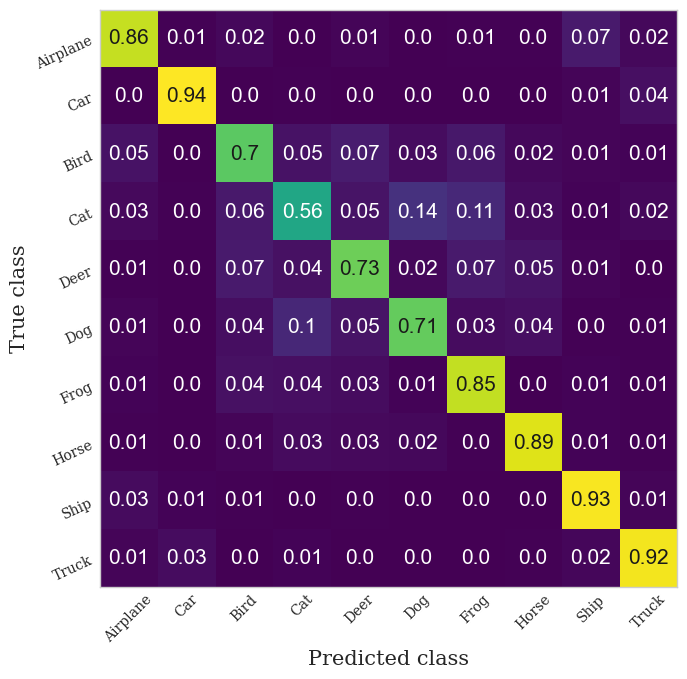

In [19]:
plot_confusion_matrix(model, testloader, normalize='true')

### Adversarial Images

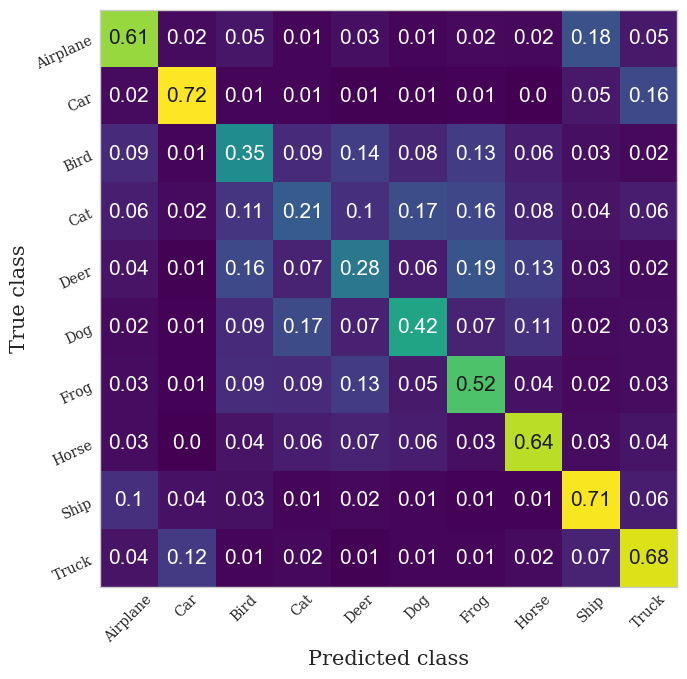

In [20]:
plot_confusion_matrix(model, testloader, normalize='true', attack=pgd_attack)

## Grad-CAM on a Clean Image

Grad-CAM is applied to a clean input image in order to visualize which image regions contribute most strongly to the predicted class.

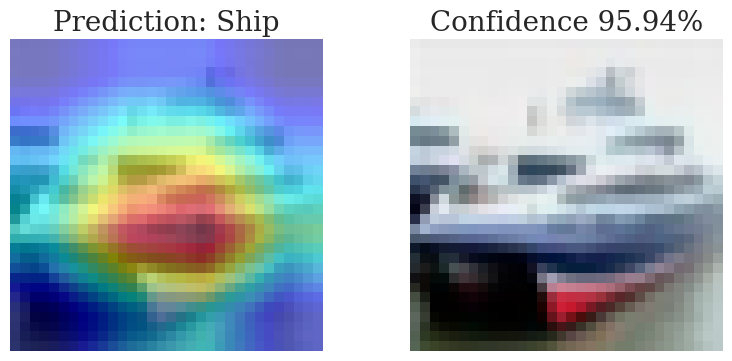

In [ ]:
idx = 1

plot_grad_cam(model, images[idx])

## Grad-CAM on an Adversarial Image

Grad-CAM is applied to an adversarially perturbed image in order to examine how the model's attention shifts after the attack.

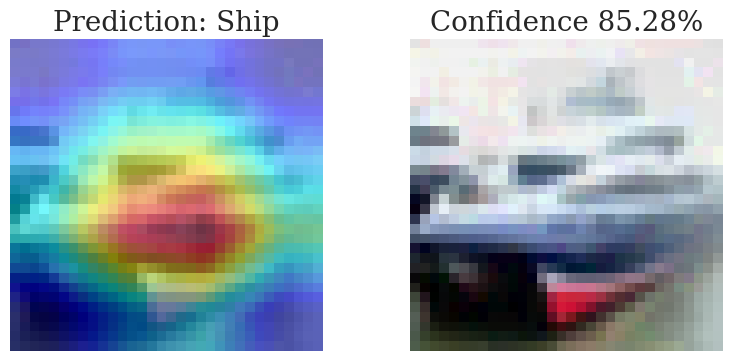

In [ ]:
adv_example = generate_adversarial_example(images[idx], labels[idx], pgd_attack)
plot_grad_cam(model, adv_example)

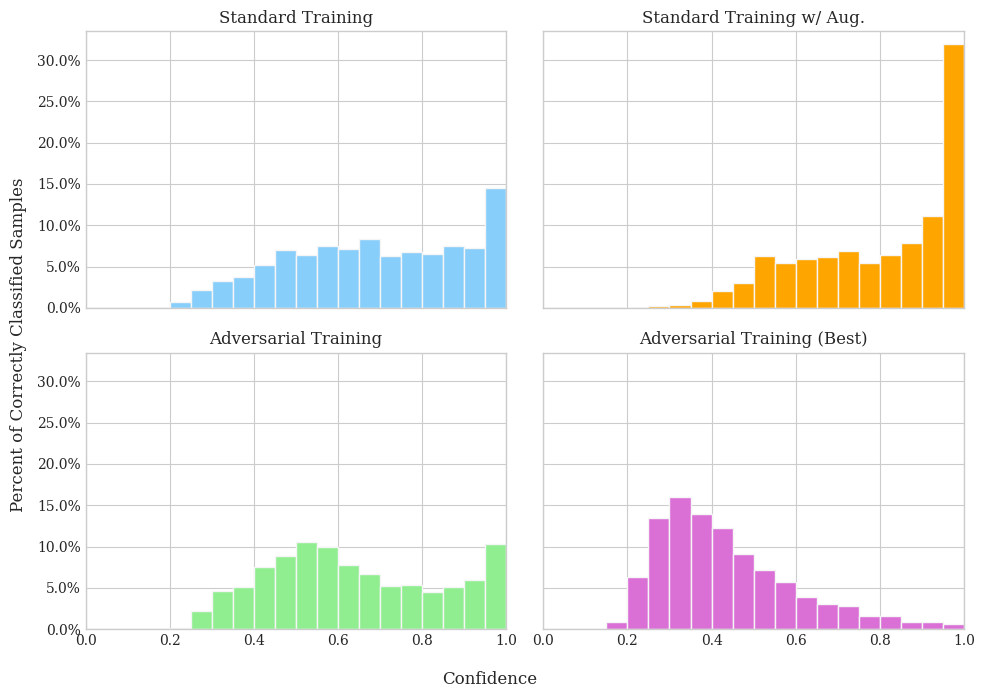

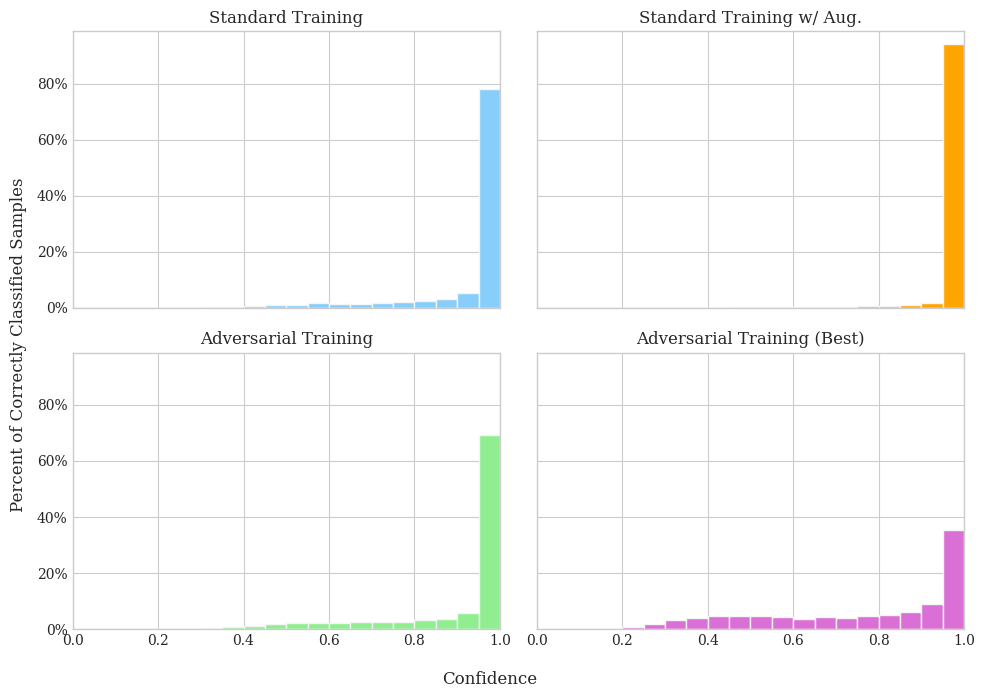

In [ ]:
standardly_trained = resnet18().to(device)
standardly_trained.load_state_dict(
    torch.load('../models/model_standard_training.pt', weights_only=True, map_location=device)
)
standardly_trained.eval()

standardly_trained_w_aug = resnet18().to(device)
standardly_trained_w_aug.load_state_dict(
    torch.load('../models/model_standard_training_with_aug.pt', weights_only=True, map_location=device)
)
standardly_trained_w_aug.eval()

adversarially_trained = resnet18().to(device)
adversarially_trained.load_state_dict(
    torch.load('../models/model_adversarial_training.pt', weights_only=True, map_location=device)
)
adversarially_trained.eval()

adversarially_trained_best = resnet18().to(device)
adversarially_trained_best.load_state_dict(
    torch.load('../models/model_adversarial_training_best.pt', weights_only=True, map_location=device)
)
adversarially_trained_best.eval()

correct_confidences_st, incorrect_confidences_st = get_confidences(
    model=standardly_trained,
    dataloader=testloader,
    device=device,
    attack=None,
)

correct_confidences_st_aug, incorrect_confidences_st_aug = get_confidences(
    model=standardly_trained_w_aug,
    dataloader=testloader,
    device=device,
    attack=None,
)

correct_confidences_at, incorrect_confidences_at = get_confidences(
    model=adversarially_trained,
    dataloader=testloader,
    device=device,
    attack=None,
)

correct_confidences_at_best, incorrect_confidences_at_best = get_confidences(
    model=adversarially_trained_best,
    dataloader=testloader,
    device=device,
    attack=None,
)

model_titles = [
    "Standard Training",
    "Standard Training w/ Aug.",
    "Adversarial Training",
    "Adversarial Training (Best)"
]

incorrect_confidences = [
    incorrect_confidences_st,
    incorrect_confidences_st_aug,
    incorrect_confidences_at,
    incorrect_confidences_at_best
]

plot_confidence_histograms(
    confidences=incorrect_confidences,
    titles=model_titles,
)

correct_confidences = [
    correct_confidences_st,
    correct_confidences_st_aug,
    correct_confidences_at,
    correct_confidences_at_best
]

plot_confidence_histograms(
    confidences=correct_confidences,
    titles=model_titles
)